# Part II final extraction and prototype analysis notebook

This notebook builds the **Part II extraction pipeline** for the occlusion study from the current folder-based BGMM output structure.

It loads all `top10_clusters.jsonl` files under two model roots:

- a **shape-biased** model root
- a **texture-biased** model root

and across all available occluder-size subfolders, such as:

- `size_16`
- `size_32`

Each `top10_clusters.jsonl` file contains one row per cluster for one case.

The main confirmatory Part II outcome extracted here is:

- `debiased_entropy`

computed from normalized `mass_debias` within each:

- `case_id × model_type × occluder_size`

This notebook has four purposes:

1. parse and audit the raw JSONL outputs
2. compute case-level hypothesis-distribution metrics
3. export clean tables for the later confirmatory Part II analysis
4. prepare top-cluster outputs for later Part III stimulus selection

Secondary metrics are included as **descriptive / exploratory** summaries only.

In [1]:
from __future__ import annotations

import json
import re
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy import stats

In [2]:
# Display and plotting defaults
pd.set_option("display.max_columns", 200)
pd.set_option("display.width", 180)
pd.set_option("display.max_rows", 200)

plt.rcParams["figure.dpi"] = 140
plt.rcParams["savefig.dpi"] = 300
plt.rcParams["figure.figsize"] = (7.8, 4.8)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False
plt.rcParams["axes.grid"] = False
plt.rcParams["font.size"] = 11

RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)

## User-editable input paths

Edit these paths before running the notebook.

This version assumes:
- one root folder for the texture-biased model
- one root folder for the shape-biased model
- within each model root, outputs are organized into subfolders such as `size_16`, `size_32`
- within each size folder, each case has its own subfolder containing `top10_clusters.jsonl`

In [3]:
shape_root = Path(
    "/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_geirhos_tl"
)

texture_root = Path(
    "/home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_tl_20250829"
)

output_dir = Path("./part2_outputs")
output_dir.mkdir(parents=True, exist_ok=True)

fig_dir = output_dir / "figures"
fig_dir.mkdir(parents=True, exist_ok=True)

print("Shape-biased root:", shape_root)
print("Texture-biased root:", texture_root)
print("Output directory:", output_dir.resolve())

Shape-biased root: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_geirhos_tl
Texture-biased root: /home/hschatzle/data/storage-occ-v2/repos/monte-carlo-selection/results/occlusion/bgmm_generated_size16_both_models/source_resnet50_tl_20250829
Output directory: /data/storage-occ-v2/repos/monte-carlo-selection/notebooks/part2_outputs


## Helper functions

These functions:
- find all `top10_clusters.jsonl` files
- read JSONL records
- infer `occluder_size` from path segments such as `size_16`
- summarize the nested `shapes` field
- normalize debiased cluster mass
- compute entropy-based case-level metrics

In [4]:
def find_cluster_jsonl_files(root: Path) -> list[Path]:
    """
    Recursively find all top10_clusters.jsonl files under a model root.
    """
    return sorted(root.rglob("top10_clusters.jsonl"))


def read_jsonl(path: Path) -> list[dict]:
    """
    Read a JSONL file into a list of dictionaries.
    Blank lines are ignored.
    """
    records = []
    with path.open("r", encoding="utf-8") as f:
        for line_number, line in enumerate(f, start=1):
            line = line.strip()
            if not line:
                continue
            try:
                records.append(json.loads(line))
            except json.JSONDecodeError as e:
                raise ValueError(f"JSON parse error in {path} on line {line_number}") from e
    return records


def infer_occluder_size_from_path(path: Path):
    """
    Infer occluder size from a path segment like 'size_16'.
    """
    path_str = str(path)
    match = re.search(r"(?:/|\\)size_(\d+)(?:/|\\)", path_str)
    if match:
        return int(match.group(1))
    return pd.NA


def load_one_cluster_file(path: Path, model_type: str) -> pd.DataFrame:
    """
    Load one cluster JSONL file and annotate it with model and path metadata.
    """
    records = read_jsonl(path)
    df = pd.DataFrame(records).copy()

    df["model_type"] = model_type
    df["source_file"] = str(path)
    df["source_case_folder"] = path.parent.name
    df["occluder_size"] = infer_occluder_size_from_path(path)

    return df


def load_cluster_folder(root: Path, model_type: str) -> pd.DataFrame:
    """
    Load all top10_clusters.jsonl files under a model root.
    """
    files = find_cluster_jsonl_files(root)

    if len(files) == 0:
        raise FileNotFoundError(f"No top10_clusters.jsonl files found under {root}")

    frames = [load_one_cluster_file(file_path, model_type=model_type) for file_path in files]
    return pd.concat(frames, axis=0, ignore_index=True)


def parse_case_id(case_id: str) -> dict:
    """
    Preserve case identifiers transparently.

    At the current stage, case_id itself is the main unit identifier.
    case_base_id is kept equal to case_id for compatibility with later scaling.
    """
    return {
        "case_id_original": case_id,
        "case_base_id": case_id if isinstance(case_id, str) else pd.NA,
    }


def summarize_shapes_field(shapes: object) -> dict:
    """
    Compute cluster-level summaries from the nested 'shapes' field.
    """
    if not isinstance(shapes, list) or len(shapes) == 0:
        return {
            "n_shapes_in_cluster": 0,
            "mean_resp": np.nan,
            "max_resp": np.nan,
            "min_resp": np.nan,
            "representative_png": pd.NA,
        }

    resp_values = []
    representative_png = pd.NA

    for item in shapes:
        if isinstance(item, dict):
            if pd.isna(representative_png) and item.get("png") is not None:
                representative_png = item.get("png")
            if item.get("resp") is not None:
                resp_values.append(item.get("resp"))

    if len(resp_values) == 0:
        return {
            "n_shapes_in_cluster": len(shapes),
            "mean_resp": np.nan,
            "max_resp": np.nan,
            "min_resp": np.nan,
            "representative_png": representative_png,
        }

    arr = np.asarray(resp_values, dtype=float)
    return {
        "n_shapes_in_cluster": len(shapes),
        "mean_resp": float(np.mean(arr)),
        "max_resp": float(np.max(arr)),
        "min_resp": float(np.min(arr)),
        "representative_png": representative_png,
    }


def unpack_shape_record(x: object) -> dict:
    """
    Expand one shape record from the nested shapes list.
    """
    if isinstance(x, dict):
        return {
            "eligible_row": x.get("eligible_row", pd.NA),
            "global_index": x.get("global_index", pd.NA),
            "png": x.get("png", pd.NA),
            "resp": x.get("resp", np.nan),
        }

    return {
        "eligible_row": pd.NA,
        "global_index": pd.NA,
        "png": pd.NA,
        "resp": np.nan,
    }


def safe_normalize_nonnegative(values: np.ndarray) -> np.ndarray:
    """
    Normalize a nonnegative vector to sum to 1.
    Negative values are clipped to 0 for safety.
    """
    values = np.asarray(values, dtype=float)
    values = np.clip(values, a_min=0.0, a_max=None)
    total = values.sum()

    if total <= 0:
        return np.zeros_like(values, dtype=float)

    return values / total


def shannon_entropy_from_probs(probs: np.ndarray) -> float:
    """
    Shannon entropy:
        H = -sum(p_i * log(p_i))
    using the natural logarithm.
    """
    probs = np.asarray(probs, dtype=float)
    probs = probs[probs > 0]

    if probs.size == 0:
        return 0.0

    return float(-(probs * np.log(probs)).sum())


def effective_number_of_hypotheses(entropy: float) -> float:
    """
    Effective number of hypotheses:
        exp(H)
    """
    return float(np.exp(entropy))

## Load and combine all cluster files from both model roots

This block:
- finds all `top10_clusters.jsonl` files under each model root
- reads all rows from all files
- adds `model_type`
- combines everything into one long dataframe

In [5]:
shape_df = load_cluster_folder(shape_root, model_type="shape_biased")
texture_df = load_cluster_folder(texture_root, model_type="texture_biased")

combined_df = pd.concat([shape_df, texture_df], axis=0, ignore_index=True)

required_columns = [
    "timestamp_utc",
    "case_id",
    "cluster_rank",
    "k",
    "mix_weight",
    "mass_debias",
    "shapes",
    "model_type",
    "occluder_size",
]

missing_required = [col for col in required_columns if col not in combined_df.columns]
if missing_required:
    raise ValueError(f"Missing required columns: {missing_required}")

combined_df = combined_df.copy()

print("Combined dataframe shape:", combined_df.shape)
display(combined_df.head())

Combined dataframe shape: (3186, 11)


,timestamp_utc,case_id,cluster_rank,k,mix_weight,mass_debias,shapes,model_type,source_file,source_case_folder,occluder_size
0,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,"[{'eligible_row': 409, 'global_index': 409, 'p...",shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16
1,2026-03-23T17:13:42+00:00,ns_cow_202,2,22,0.033225,332.102437,"[{'eligible_row': 5880, 'global_index': 5880, ...",shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16
2,2026-03-23T17:13:42+00:00,ns_cow_202,3,74,0.031869,323.906268,"[{'eligible_row': 557, 'global_index': 557, 'p...",shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16
3,2026-03-23T17:13:42+00:00,ns_cow_202,4,77,0.028156,287.485383,"[{'eligible_row': 4762, 'global_index': 4762, ...",shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16
4,2026-03-23T17:13:42+00:00,ns_cow_202,5,66,0.027825,280.880935,"[{'eligible_row': 1722, 'global_index': 1722, ...",shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16


## Data audit

This section checks:
- shape
- columns
- dtypes
- missing values
- duplicate rows
- unique `case_id`s
- unique `cluster_rank`s
- row counts per model
- number of source files per model
- detected occluder-size levels
- summaries of `mix_weight` and `mass_debias`

In [6]:
print("Shape:")
print(combined_df.shape)

print("\nColumns:")
print(list(combined_df.columns))

print("\nDtypes:")
display(combined_df.dtypes.to_frame("dtype"))

Shape:
(3186, 11)

Columns:
['timestamp_utc', 'case_id', 'cluster_rank', 'k', 'mix_weight', 'mass_debias', 'shapes', 'model_type', 'source_file', 'source_case_folder', 'occluder_size']

Dtypes:


,dtype
timestamp_utc,object
case_id,object
cluster_rank,int64
k,int64
mix_weight,float64
mass_debias,float64
shapes,object
model_type,object
source_file,object
source_case_folder,object


In [7]:
print("Row counts per model_type:")
display(combined_df["model_type"].value_counts(dropna=False).rename_axis("model_type").to_frame("n_rows"))

print("Number of unique source files per model_type:")
display(
    combined_df.groupby("model_type")["source_file"].nunique().rename("n_files").reset_index()
)

print("Basic summaries for mix_weight and mass_debias:")
display(combined_df[["mix_weight", "mass_debias"]].describe().T)

Row counts per model_type:


,n_rows
model_type,
shape_biased,1600
texture_biased,1586


Number of unique source files per model_type:


,model_type,n_files
0,shape_biased,160
1,texture_biased,159


Basic summaries for mix_weight and mass_debias:


,count,mean,std,min,25%,50%,75%,max
mix_weight,3186.0,0.028984,0.025881,0.000100,0.015138,0.022363,0.033126,0.562955
mass_debias,3186.0,314.210357,276.708420,31.261191,160.109566,246.069751,358.731250,4648.029149


## Parse metadata from `case_id`

At the current stage:
- `occluder_size` is inferred from the folder path
- `case_id` is retained as the primary case identifier
- `case_base_id` is kept equal to `case_id` for compatibility with later extensions

This keeps the workflow transparent and easy to scale later.

In [8]:
parsed_case_meta = combined_df["case_id"].apply(parse_case_id).apply(pd.Series)

combined_df = pd.concat(
    [combined_df, parsed_case_meta[["case_base_id"]]],
    axis=1,
)

display(
    combined_df[
        ["case_id", "case_base_id", "occluder_size", "model_type", "source_case_folder"]
    ].drop_duplicates().sort_values(["model_type", "occluder_size", "case_id"]).head(30)
)

,case_id,case_base_id,occluder_size,model_type,source_case_folder
1200,ns_cow_202,ns_cow_202,8,shape_biased,ns_cow_202
1210,ns_cow_205,ns_cow_205,8,shape_biased,ns_cow_205
1220,ns_cow_350,ns_cow_350,8,shape_biased,ns_cow_350
1230,ns_cow_510,ns_cow_510,8,shape_biased,ns_cow_510
1240,ns_cow_780,ns_cow_780,8,shape_biased,ns_cow_780
1250,ns_dog_105,ns_dog_105,8,shape_biased,ns_dog_105
1260,ns_dog_214,ns_dog_214,8,shape_biased,ns_dog_214
1270,ns_dog_350,ns_dog_350,8,shape_biased,ns_dog_350
1280,ns_dog_69,ns_dog_69,8,shape_biased,ns_dog_69
1290,ns_dog_780,ns_dog_780,8,shape_biased,ns_dog_780


## Expand and summarize the `shapes` field

At the cluster level, this block computes:
- `n_shapes_in_cluster`
- mean `resp`
- max `resp`
- min `resp`

It also creates an exploded long dataframe with one row per shape.

In [9]:
shape_summaries = combined_df["shapes"].apply(summarize_shapes_field).apply(pd.Series)
combined_df = pd.concat([combined_df, shape_summaries], axis=1)

display(
    combined_df[
        [
            "case_id",
            "occluder_size",
            "model_type",
            "cluster_rank",
            "n_shapes_in_cluster",
            "mean_resp",
            "max_resp",
            "min_resp",
            "representative_png",
        ]
    ].head(10)
)

,case_id,occluder_size,model_type,cluster_rank,n_shapes_in_cluster,mean_resp,max_resp,min_resp,representative_png
0,ns_cow_202,16,shape_biased,1,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
1,ns_cow_202,16,shape_biased,2,25,0.999999,1.0,0.999998,/data/storage-occ-v2/repos/monte-carlo-selecti...
2,ns_cow_202,16,shape_biased,3,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
3,ns_cow_202,16,shape_biased,4,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
4,ns_cow_202,16,shape_biased,5,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
5,ns_cow_202,16,shape_biased,6,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
6,ns_cow_202,16,shape_biased,7,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
7,ns_cow_202,16,shape_biased,8,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
8,ns_cow_202,16,shape_biased,9,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
9,ns_cow_202,16,shape_biased,10,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...


In [10]:
exploded_shapes_df = combined_df.copy().explode("shapes", ignore_index=True)

shape_detail_cols = exploded_shapes_df["shapes"].apply(unpack_shape_record).apply(pd.Series)
exploded_shapes_df = pd.concat(
    [exploded_shapes_df.drop(columns=["shapes"]), shape_detail_cols],
    axis=1,
)

print("Exploded shapes dataframe shape:", exploded_shapes_df.shape)
display(exploded_shapes_df.head(10))

Exploded shapes dataframe shape: (79650, 20)


,timestamp_utc,case_id,cluster_rank,k,mix_weight,mass_debias,model_type,source_file,source_case_folder,occluder_size,case_base_id,n_shapes_in_cluster,mean_resp,max_resp,min_resp,representative_png,eligible_row,global_index,png,resp
0,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,409,409,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
1,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,4090,4090,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
2,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,2655,2655,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
3,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,7184,7184,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
4,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,4251,4251,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
5,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,2519,2519,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
6,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,405,405,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
7,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,6626,6626,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
8,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,9316,9316,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0
9,2026-03-23T17:13:42+00:00,ns_cow_202,1,50,0.043187,434.106142,shape_biased,/home/hschatzle/data/storage-occ-v2/repos/mont...,ns_cow_202,16,ns_cow_202,25,1.0,1.0,1.0,/data/storage-occ-v2/repos/monte-carlo-selecti...,1460,1460,/data/storage-occ-v2/repos/monte-carlo-selecti...,1.0


## Compute the confirmatory Part II metric

The primary confirmatory metric is **debiased entropy**.

For each:

- `case_id × model_type × occluder_size`

we:
1. normalize `mass_debias` into debiased mass proportions
2. compute Shannon entropy:


$$H = -\sum_i p_i \log(p_i)$$

Lower entropy indicates a more selective hypothesis distribution.

In [11]:
combined_df = combined_df.copy()
combined_df["mass_debias_nonnegative"] = combined_df["mass_debias"].clip(lower=0)

combined_df["normalized_debiased_mass"] = (
    combined_df
    .groupby(["case_id", "model_type", "occluder_size"])["mass_debias_nonnegative"]
    .transform(lambda s: s / s.sum() if s.sum() > 0 else np.zeros(len(s), dtype=float))
)

display(
    combined_df[
        [
            "case_id",
            "occluder_size",
            "model_type",
            "cluster_rank",
            "mass_debias",
            "normalized_debiased_mass",
        ]
    ].head(12)
)

,case_id,occluder_size,model_type,cluster_rank,mass_debias,normalized_debiased_mass
0,ns_cow_202,16,shape_biased,1,434.106142,0.146591
1,ns_cow_202,16,shape_biased,2,332.102437,0.112146
2,ns_cow_202,16,shape_biased,3,323.906268,0.109378
3,ns_cow_202,16,shape_biased,4,287.485383,0.097079
4,ns_cow_202,16,shape_biased,5,280.880935,0.094849
5,ns_cow_202,16,shape_biased,6,280.525207,0.094729
6,ns_cow_202,16,shape_biased,7,280.497271,0.094720
7,ns_cow_202,16,shape_biased,8,251.873252,0.085054
8,ns_cow_202,16,shape_biased,9,246.052257,0.083088
9,ns_cow_202,16,shape_biased,10,243.914623,0.082366


In [12]:
def compute_case_level_metrics(group: pd.DataFrame) -> pd.Series:
    probs = group["normalized_debiased_mass"].to_numpy(dtype=float)
    entropy = shannon_entropy_from_probs(probs)
    sorted_probs = np.sort(probs)[::-1]

    max_prop = float(sorted_probs[0]) if sorted_probs.size >= 1 else np.nan
    top2_prop = float(sorted_probs[:2].sum()) if sorted_probs.size >= 1 else np.nan

    return pd.Series(
        {
            "n_clusters": int(len(group)),
            "debiased_entropy": entropy,
            "max_debiased_mass_prop": max_prop,
            "top2_debiased_mass_prop": top2_prop,
            "effective_n_hypotheses": effective_number_of_hypotheses(entropy),
            "sum_mass_debias_nonnegative": float(group["mass_debias_nonnegative"].sum()),
            "mean_cluster_n_shapes": float(group["n_shapes_in_cluster"].mean()),
        }
    )


case_metrics_df = (
    combined_df
    .groupby(["case_id", "model_type", "occluder_size", "case_base_id"], dropna=False)
    .apply(compute_case_level_metrics)
    .reset_index()
)

display(case_metrics_df.head(20))

/data/storage-occ-v2/pip-tmp/ipykernel_3972074/4142806630.py:25: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(compute_case_level_metrics)


,case_id,model_type,occluder_size,case_base_id,n_clusters,debiased_entropy,max_debiased_mass_prop,top2_debiased_mass_prop,effective_n_hypotheses,sum_mass_debias_nonnegative,mean_cluster_n_shapes
0,ns_cow_202,shape_biased,8,ns_cow_202,10.0,1.948985,0.378319,0.500004,7.021560,7144.782119,25.0
1,ns_cow_202,shape_biased,16,ns_cow_202,10.0,2.287160,0.146591,0.258737,9.846937,2961.343776,25.0
2,ns_cow_202,shape_biased,32,ns_cow_202,10.0,2.251765,0.148855,0.296493,9.504496,4418.757491,25.0
3,ns_cow_202,shape_biased,64,ns_cow_202,10.0,2.219188,0.189145,0.363797,9.199860,4698.274237,25.0
4,ns_cow_202,texture_biased,8,ns_cow_202,10.0,2.302585,0.100035,0.200061,10.000000,1256.818502,25.0
5,ns_cow_202,texture_biased,16,ns_cow_202,10.0,2.302585,0.100057,0.200099,9.999999,1312.066238,25.0
6,ns_cow_202,texture_biased,32,ns_cow_202,10.0,2.217482,0.196995,0.374983,9.184178,2425.876245,25.0
7,ns_cow_202,texture_biased,64,ns_cow_202,10.0,2.291856,0.128769,0.242488,9.893283,4273.027236,25.0
8,ns_cow_205,shape_biased,8,ns_cow_205,10.0,2.295751,0.109766,0.219087,9.931887,1856.088200,25.0
9,ns_cow_205,shape_biased,16,ns_cow_205,10.0,2.067463,0.253914,0.486814,7.904743,4024.616378,25.0


## Secondary / descriptive metrics and top clusters

The following quantities are treated as **secondary / exploratory** in this notebook:

- maximum debiased mass proportion
- top-2 cumulative debiased mass proportion
- effective number of hypotheses
- number of clusters

We also retain the top 5 clusters per:

- `case_id × model_type × occluder_size`

In [13]:
top5_clusters_df = (
    combined_df
    .sort_values(
        by=["case_id", "model_type", "occluder_size", "normalized_debiased_mass", "cluster_rank"],
        ascending=[True, True, True, False, True]
    )
    .groupby(["case_id", "model_type", "occluder_size"], dropna=False)
    .head(5)
    .reset_index(drop=True)
)

top5_clusters_df = top5_clusters_df[
    [
        "case_id",
        "case_base_id",
        "occluder_size",
        "model_type",
        "cluster_rank",
        "k",
        "mix_weight",
        "mass_debias",
        "normalized_debiased_mass",
        "n_shapes_in_cluster",
        "mean_resp",
        "max_resp",
        "min_resp",
        "representative_png",
        "source_file",
    ]
].copy()

display(top5_clusters_df.head(20))

,case_id,case_base_id,occluder_size,model_type,cluster_rank,k,mix_weight,mass_debias,normalized_debiased_mass,n_shapes_in_cluster,mean_resp,max_resp,min_resp,representative_png,source_file
0,ns_cow_202,ns_cow_202,8,shape_biased,1,49,0.268479,2703.006453,0.378319,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
1,ns_cow_202,ns_cow_202,8,shape_biased,2,23,0.086802,869.415124,0.121685,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
2,ns_cow_202,ns_cow_202,8,shape_biased,3,76,0.072142,740.987889,0.103710,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
3,ns_cow_202,ns_cow_202,8,shape_biased,4,0,0.069230,691.371770,0.096766,25,1.000000,1.0,0.999999,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
4,ns_cow_202,ns_cow_202,8,shape_biased,5,28,0.061579,616.928520,0.086347,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
5,ns_cow_202,ns_cow_202,16,shape_biased,1,50,0.043187,434.106142,0.146591,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
6,ns_cow_202,ns_cow_202,16,shape_biased,2,22,0.033225,332.102437,0.112146,25,0.999999,1.0,0.999998,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
7,ns_cow_202,ns_cow_202,16,shape_biased,3,74,0.031869,323.906268,0.109378,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
8,ns_cow_202,ns_cow_202,16,shape_biased,4,77,0.028156,287.485383,0.097079,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...
9,ns_cow_202,ns_cow_202,16,shape_biased,5,66,0.027825,280.880935,0.094849,25,1.000000,1.0,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...,/home/hschatzle/data/storage-occ-v2/repos/mont...


## Descriptive summaries

These summaries describe the extracted metrics by:
- model type
- occluder size
- model type × occluder size

They are useful for quality control and early pattern inspection, but they do not replace the final confirmatory model.

In [14]:
summary_by_model = (
    case_metrics_df
    .groupby("model_type", dropna=False)
    .agg(
        n_cases=("case_id", "nunique"),
        mean_debiased_entropy=("debiased_entropy", "mean"),
        sd_debiased_entropy=("debiased_entropy", "std"),
        mean_max_mass=("max_debiased_mass_prop", "mean"),
        mean_top2_mass=("top2_debiased_mass_prop", "mean"),
        avg_n_clusters=("n_clusters", "mean"),
        mean_effective_n_hypotheses=("effective_n_hypotheses", "mean"),
    )
    .reset_index()
)

summary_by_size = (
    case_metrics_df
    .groupby("occluder_size", dropna=False)
    .agg(
        n_rows=("case_id", "count"),
        n_cases=("case_id", "nunique"),
        mean_debiased_entropy=("debiased_entropy", "mean"),
        sd_debiased_entropy=("debiased_entropy", "std"),
    )
    .reset_index()
)

summary_by_model_size = (
    case_metrics_df
    .groupby(["model_type", "occluder_size"], dropna=False)
    .agg(
        n_rows=("case_id", "count"),
        n_cases=("case_id", "nunique"),
        mean_debiased_entropy=("debiased_entropy", "mean"),
        sd_debiased_entropy=("debiased_entropy", "std"),
        mean_max_mass=("max_debiased_mass_prop", "mean"),
        mean_top2_mass=("top2_debiased_mass_prop", "mean"),
        avg_n_clusters=("n_clusters", "mean"),
    )
    .reset_index()
)

display(summary_by_model)
display(summary_by_size)
display(summary_by_model_size)

,model_type,n_cases,mean_debiased_entropy,sd_debiased_entropy,mean_max_mass,mean_top2_mass,avg_n_clusters,mean_effective_n_hypotheses
0,shape_biased,40,2.226820,0.107353,0.180475,0.315172,10.000000,9.317913
1,texture_biased,40,2.257375,0.100272,0.148757,0.268021,9.974843,9.598247


,occluder_size,n_rows,n_cases,mean_debiased_entropy,sd_debiased_entropy
0,8,79,40,2.255872,0.133177
1,16,80,40,2.251705,0.076329
2,32,80,40,2.241049,0.088600
3,64,80,40,2.219745,0.110764


,model_type,occluder_size,n_rows,n_cases,mean_debiased_entropy,sd_debiased_entropy,mean_max_mass,mean_top2_mass,avg_n_clusters
0,shape_biased,8,40,40,2.249617,0.093860,0.159675,0.282986,10.000000
1,shape_biased,16,40,40,2.230579,0.086844,0.177797,0.312946,10.000000
2,shape_biased,32,40,40,2.224797,0.104970,0.185636,0.320026,10.000000
3,shape_biased,64,40,40,2.202289,0.135816,0.198791,0.344728,10.000000
4,texture_biased,8,39,39,2.262289,0.165169,0.120960,0.229226,9.897436
5,texture_biased,16,40,40,2.272831,0.057829,0.139029,0.254071,10.000000
6,texture_biased,32,40,40,2.257301,0.065884,0.159378,0.279846,10.000000
7,texture_biased,64,40,40,2.237202,0.076032,0.174965,0.307972,10.000000


## Plot 1. Cluster rank versus raw `mass_debias`

This plot shows the average raw debiased mass across cluster rank separately for the two model types.

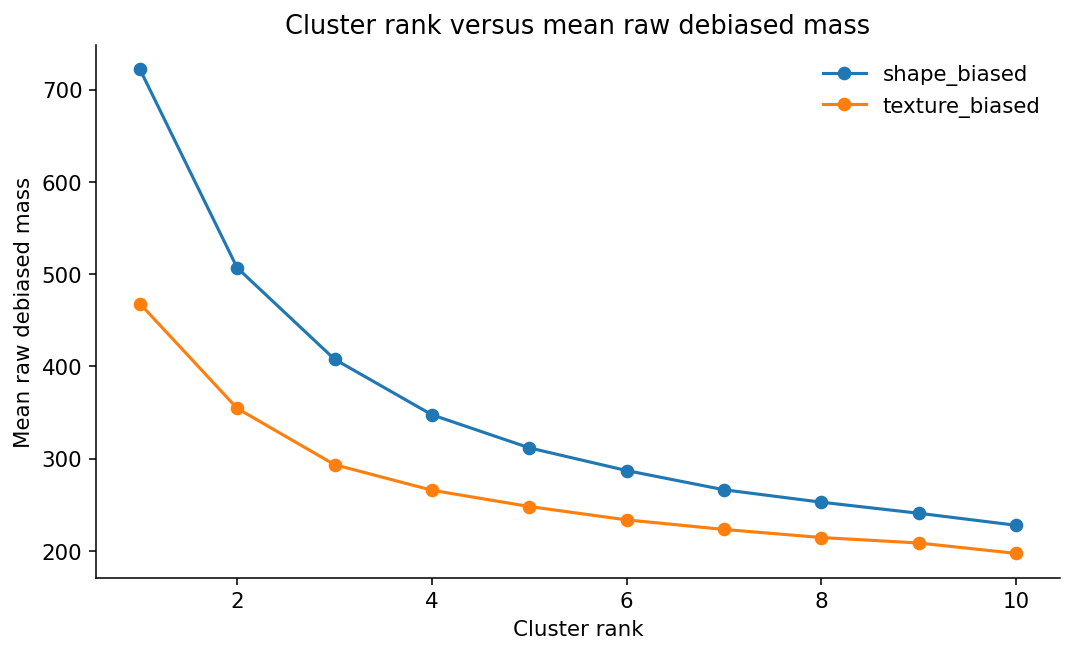

In [15]:
rank_mass_df = (
    combined_df
    .groupby(["model_type", "cluster_rank"], as_index=False)["mass_debias"]
    .mean()
)

fig, ax = plt.subplots()

for model_type, df_sub in rank_mass_df.groupby("model_type"):
    df_sub = df_sub.sort_values("cluster_rank")
    ax.plot(
        df_sub["cluster_rank"],
        df_sub["mass_debias"],
        marker="o",
        linewidth=1.6,
        label=model_type,
    )

ax.set_xlabel("Cluster rank")
ax.set_ylabel("Mean raw debiased mass")
ax.set_title("Cluster rank versus mean raw debiased mass")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "cluster_rank_vs_raw_mass_debias.png", bbox_inches="tight")
plt.show()

## Plot 2. Cluster rank versus normalized debiased mass

This plot compares the average normalized debiased mass distribution across rank for the two model types.

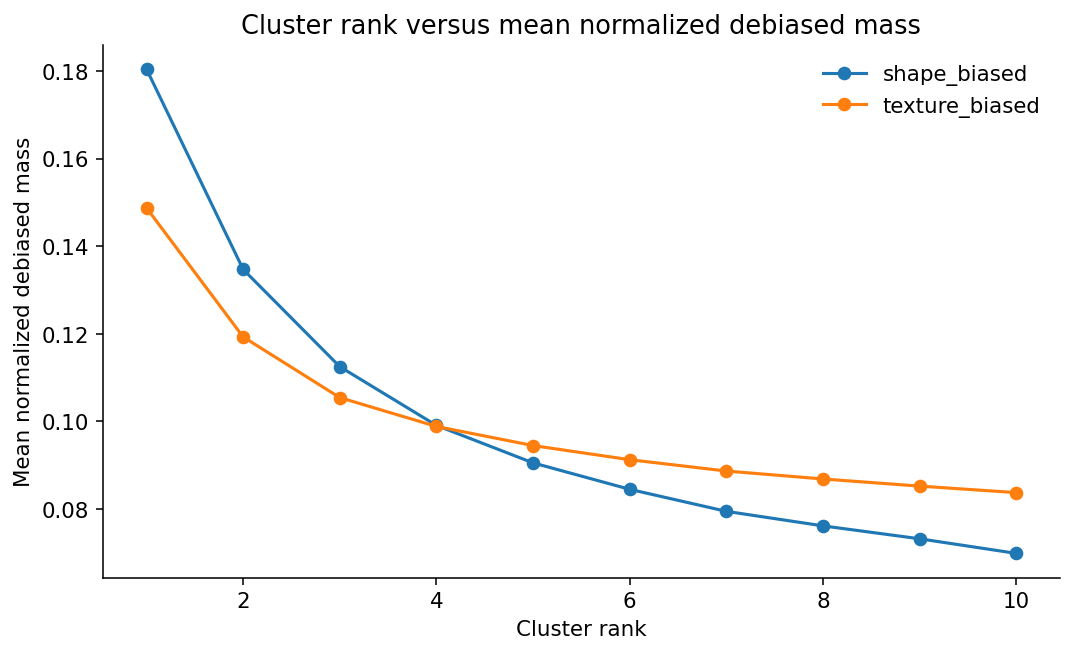

In [16]:
rank_norm_df = (
    combined_df
    .groupby(["model_type", "cluster_rank"], as_index=False)["normalized_debiased_mass"]
    .mean()
)

fig, ax = plt.subplots()

for model_type, df_sub in rank_norm_df.groupby("model_type"):
    df_sub = df_sub.sort_values("cluster_rank")
    ax.plot(
        df_sub["cluster_rank"],
        df_sub["normalized_debiased_mass"],
        marker="o",
        linewidth=1.6,
        label=model_type,
    )

ax.set_xlabel("Cluster rank")
ax.set_ylabel("Mean normalized debiased mass")
ax.set_title("Cluster rank versus mean normalized debiased mass")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "cluster_rank_vs_normalized_debiased_mass.png", bbox_inches="tight")
plt.show()

## Plot 3. Cumulative normalized mass across cluster rank

A steeper cumulative curve indicates that more mass is concentrated in the top-ranked clusters.

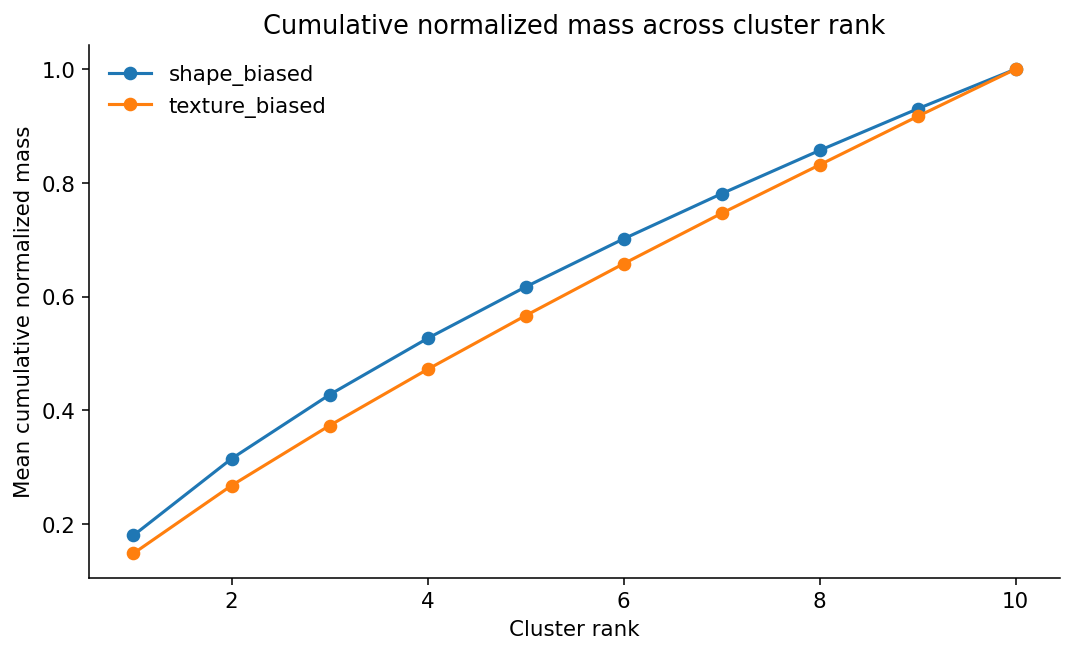

In [17]:
fig, ax = plt.subplots()

for model_type, df_sub in combined_df.groupby("model_type"):
    cumulative_rows = []

    for keys, case_sub in df_sub.groupby(["case_id", "occluder_size"]):
        case_sub = case_sub.sort_values("cluster_rank").copy()
        case_sub["cumulative_mass"] = case_sub["normalized_debiased_mass"].cumsum()
        cumulative_rows.append(case_sub[["cluster_rank", "cumulative_mass"]])

    cumulative_df = pd.concat(cumulative_rows, ignore_index=True)

    mean_curve = (
        cumulative_df
        .groupby("cluster_rank", as_index=False)["cumulative_mass"]
        .mean()
        .sort_values("cluster_rank")
    )

    ax.plot(
        mean_curve["cluster_rank"],
        mean_curve["cumulative_mass"],
        marker="o",
        linewidth=1.6,
        label=model_type,
    )

ax.set_xlabel("Cluster rank")
ax.set_ylabel("Mean cumulative normalized mass")
ax.set_title("Cumulative normalized mass across cluster rank")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "cumulative_normalized_mass_across_rank.png", bbox_inches="tight")
plt.show()

## Plot 4. Debiased entropy across occluder sizes

This plot shows the mean case-level `debiased_entropy` across occluder sizes, with separate lines for each model type.

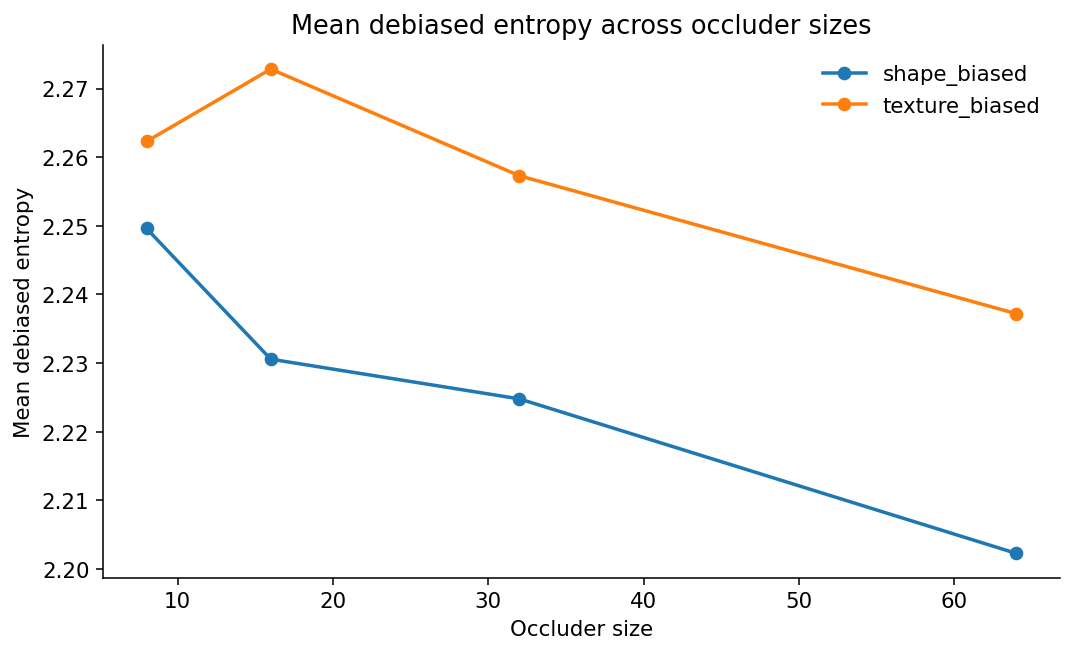

In [18]:
entropy_plot_df = (
    case_metrics_df
    .groupby(["model_type", "occluder_size"], as_index=False)["debiased_entropy"]
    .mean()
    .sort_values(["model_type", "occluder_size"])
)

fig, ax = plt.subplots()

for model_type, df_sub in entropy_plot_df.groupby("model_type"):
    ax.plot(
        df_sub["occluder_size"],
        df_sub["debiased_entropy"],
        marker="o",
        linewidth=1.8,
        label=model_type,
    )

ax.set_xlabel("Occluder size")
ax.set_ylabel("Mean debiased entropy")
ax.set_title("Mean debiased entropy across occluder sizes")
ax.legend(frameon=False)
fig.tight_layout()

fig.savefig(fig_dir / "mean_debiased_entropy_across_occluder_sizes.png", bbox_inches="tight")
plt.show()

## Optional prototype inferential check in the extraction notebook

This block performs a provisional inferential check using the extracted case-level metrics.

Because the same cases may appear under both model types within each occluder size, we first identify matched cases and then compare:

- `debiased_entropy` in the shape-biased model
- `debiased_entropy` in the texture-biased model

within each occluder size.

This is useful as a prototype analytic check, but the **final confirmatory inference** should still be conducted in the downstream Part II analysis notebook using the exported master metrics table.

In [19]:
paired_entropy_df = (
    case_metrics_df
    .pivot_table(
        index=["case_id", "occluder_size"],
        columns="model_type",
        values="debiased_entropy",
        aggfunc="first"
    )
    .reset_index()
)

paired_entropy_df.columns.name = None
display(paired_entropy_df.head(20))

,case_id,occluder_size,shape_biased,texture_biased
0,ns_cow_202,8,1.948985,2.302585
1,ns_cow_202,16,2.287160,2.302585
2,ns_cow_202,32,2.251765,2.217482
3,ns_cow_202,64,2.219188,2.291856
4,ns_cow_205,8,2.295751,2.302585
5,ns_cow_205,16,2.067463,2.253585
6,ns_cow_205,32,2.274614,2.302585
7,ns_cow_205,64,2.254416,2.232133
8,ns_cow_350,8,2.267764,2.302585
9,ns_cow_350,16,2.240068,2.298947


In [20]:
inferential_rows = []

for occ_size, sub in paired_entropy_df.groupby("occluder_size"):
    sub = sub.dropna(subset=["shape_biased", "texture_biased"]).copy()

    n_pairs = len(sub)
    if n_pairs == 0:
        continue

    sub["diff_shape_minus_texture"] = sub["shape_biased"] - sub["texture_biased"]

    t_stat, t_p = stats.ttest_rel(sub["shape_biased"], sub["texture_biased"])

    try:
        w_stat, w_p = stats.wilcoxon(sub["shape_biased"], sub["texture_biased"])
    except ValueError:
        w_stat, w_p = np.nan, np.nan

    inferential_rows.append({
        "occluder_size": occ_size,
        "n_pairs": n_pairs,
        "mean_shape_entropy": float(sub["shape_biased"].mean()),
        "mean_texture_entropy": float(sub["texture_biased"].mean()),
        "mean_diff_shape_minus_texture": float(sub["diff_shape_minus_texture"].mean()),
        "paired_t_statistic": t_stat,
        "paired_t_p_value": t_p,
        "wilcoxon_statistic": w_stat,
        "wilcoxon_p_value": w_p,
    })

prototype_inference_df = pd.DataFrame(inferential_rows)
display(prototype_inference_df)

,occluder_size,n_pairs,mean_shape_entropy,mean_texture_entropy,mean_diff_shape_minus_texture,paired_t_statistic,paired_t_p_value,wilcoxon_statistic,wilcoxon_p_value
0,8,39,2.248291,2.262289,-0.013998,-0.456200,0.650843,138.0,0.000250
1,16,40,2.230579,2.272831,-0.042252,-3.521173,0.001111,140.0,0.000150
2,32,40,2.224797,2.257301,-0.032504,-1.752482,0.087550,262.0,0.046611
3,64,40,2.202289,2.237202,-0.034913,-1.341163,0.187626,308.0,0.174354


## Prepare outputs for later Part III

This table keeps the top 5 clusters per:

- `case_id × model_type × occluder_size`

and includes:
- `case_id`
- `model_type`
- `occluder_size`
- `cluster_rank`
- `k`
- normalized debiased mass
- `n_shapes_in_cluster`
- mean `resp`
- one representative PNG path

In [21]:
top5_for_export_df = top5_clusters_df[
    [
        "case_id",
        "model_type",
        "occluder_size",
        "cluster_rank",
        "k",
        "normalized_debiased_mass",
        "n_shapes_in_cluster",
        "mean_resp",
        "representative_png",
    ]
].sort_values(
    ["case_id", "model_type", "occluder_size", "normalized_debiased_mass"],
    ascending=[True, True, True, False]
).reset_index(drop=True)

display(top5_for_export_df.head(30))

,case_id,model_type,occluder_size,cluster_rank,k,normalized_debiased_mass,n_shapes_in_cluster,mean_resp,representative_png
0,ns_cow_202,shape_biased,8,1,49,0.378319,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
1,ns_cow_202,shape_biased,8,2,23,0.121685,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
2,ns_cow_202,shape_biased,8,3,76,0.103710,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
3,ns_cow_202,shape_biased,8,4,0,0.096766,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
4,ns_cow_202,shape_biased,8,5,28,0.086347,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
5,ns_cow_202,shape_biased,16,1,50,0.146591,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
6,ns_cow_202,shape_biased,16,2,22,0.112146,25,0.999999,/data/storage-occ-v2/repos/monte-carlo-selecti...
7,ns_cow_202,shape_biased,16,3,74,0.109378,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
8,ns_cow_202,shape_biased,16,4,77,0.097079,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...
9,ns_cow_202,shape_biased,16,5,66,0.094849,25,1.000000,/data/storage-occ-v2/repos/monte-carlo-selecti...


In [22]:
top5_csv_path = output_dir / "top5_clusters_for_part3.csv"
top5_for_export_df.to_csv(top5_csv_path, index=False)

print("Saved:", top5_csv_path)

Saved: part2_outputs/top5_clusters_for_part3.csv


## Save outputs

This block saves:
- combined cluster dataframe
- exploded shapes dataframe
- case-level metrics dataframe
- top-5 cluster table
- prototype inferential summary
- figures

In [23]:
combined_csv_path = output_dir / "combined_cluster_dataframe.csv"
exploded_shapes_csv_path = output_dir / "exploded_shapes_dataframe.csv"
case_metrics_csv_path = output_dir / "part2_hypothesis_metrics_long.csv"
prototype_inference_csv_path = output_dir / "prototype_within_size_inference.csv"

combined_df.to_csv(combined_csv_path, index=False)
exploded_shapes_df.to_csv(exploded_shapes_csv_path, index=False)
case_metrics_df.to_csv(case_metrics_csv_path, index=False)
prototype_inference_df.to_csv(prototype_inference_csv_path, index=False)

print("Saved tables:")
print("-", combined_csv_path)
print("-", exploded_shapes_csv_path)
print("-", case_metrics_csv_path)
print("-", top5_csv_path)
print("-", prototype_inference_csv_path)

print("\nFigures saved in:")
print(fig_dir.resolve())

Saved tables:
- part2_outputs/combined_cluster_dataframe.csv
- part2_outputs/exploded_shapes_dataframe.csv
- part2_outputs/part2_hypothesis_metrics_long.csv
- part2_outputs/top5_clusters_for_part3.csv
- part2_outputs/prototype_within_size_inference.csv

Figures saved in:
/data/storage-occ-v2/repos/monte-carlo-selection/notebooks/part2_outputs/figures


## Interpretation notes

In the later full Part II analysis, evidence that the **shape-biased model** maintains a **more selective hypothesis distribution** than the **texture-biased model** would be reflected by patterns such as:

1. **Lower debiased entropy**
   - indicating that the debiased mass is concentrated in fewer clusters.

2. **Higher maximum debiased mass proportion**
   - indicating that one cluster dominates more strongly.

3. **Higher top-2 cumulative debiased mass**
   - indicating that the leading hypotheses account for more of the total mass.

4. **Lower effective number of hypotheses**
   - indicating a more selective effective distribution.

5. **Steeper cumulative mass curves**
   - indicating faster accumulation of total mass in the top-ranked clusters.

### Important note about inference

This notebook includes a **prototype inferential block** to help verify that the extracted case-level metrics behave sensibly across available occluder sizes.

However, the **final confirmatory Part II analysis** should be run downstream on the exported file:

- `part2_hypothesis_metrics_long.csv`

That final analysis should use the dedicated confirmatory notebook and test the preregistered model across:

- `model_type`
- `occluder_size`

### Role of this notebook in the full pipeline

This notebook is the extraction and preparation stage. It is designed to:

- parse the raw cluster JSONLs
- compute case-level Part II metrics
- export a clean master long-format metrics file
- export top-cluster summaries for later Part III stimulus selection
- provide transparent quality-control summaries before formal confirmatory modeling